In [1]:
from facenet_pytorch import MTCNN, InceptionResnetV1, fixed_image_standardization, training
import torch
import cv2
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import time

/home/pj00/anaconda3/envs/CVenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load model and tracker

In [2]:
# set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Current device: {}'.format(device))

Current device: cuda:0


In [3]:
mtcnn = MTCNN(
    image_size=160,
    margin=0,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=True,
    device=device
)

## Functions

In [4]:
def frame_norm(frame_bgr):
    temp_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    temp_frame = cv2.normalize(temp_frame, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    return temp_frame

def generate_bboxes(probs, threshold):
    thres_probs = np.where(probs>threshold)
    bboxes = []
    for idx in thres_probs[0]:
        x0, y0, x1, y1 = faces[idx].astype(int)
        w = x1 - x0
        h = y1 - y0

        bbox = (x0, y0, w, h)
        bboxes.append(bbox)
    return bboxes

def createTracker(bboxes):
    multiTracker = cv2.legacy.MultiTracker_create()
    for bbox in bboxes:
        multiTracker.add(cv2.legacy.TrackerKCF_create(), frame, bbox)
    success = True
    
    return multiTracker, success

def frame_rectangles(frame, bboxes):
    for bbox in bboxes:
        p1 = (int(bbox[0]), int(bbox[1]))
        p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
        cv2.rectangle(frame, p1, p2, (255,0,0), 2, 1)
    return frame

## Start recording

In [5]:
cap = cv2.VideoCapture(0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(width, height)

640 480


[ WARN:0@0.977] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


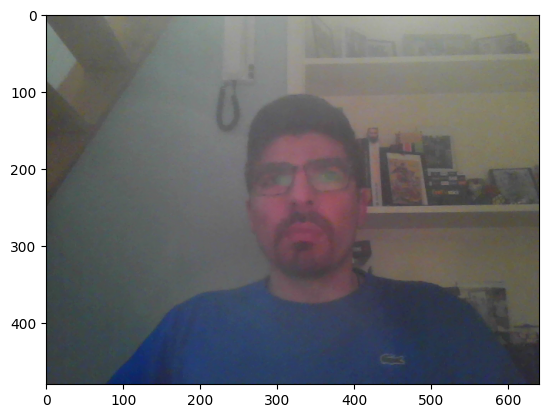

In [7]:
_, frame = cap.read()
plt.imshow(frame[:, :, ::-1])

In [16]:
multiTracker = cv2.legacy.MultiTracker_create()

In [7]:
threshold = 0.8
ssim_thresh = 0.80
sampling_frames = 30

In [8]:
prev = np.zeros([height, width]).astype('uint8')
prev = cv2.normalize(prev, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

ssims = []
frame_counter = 0

start = time.time()
while True:
    ret, frame = cap.read()
    
    # Update tracker
    success, bboxes = multiTracker.update(frame)
    
    current = frame.copy()
    current = frame_norm(current)
    
    if not frame_counter%sampling_frames:
        ssims.append(ssim(current, prev, data_range=2))
        prev = current.copy()
    
        # major changes in image
        if ssims[-1] < ssim_thresh:
            # detect faces within the frame
            faces, probs = mtcnn.detect(frame[:,:,::-1])

            # run only if faces are detected
            if probs.any():
                bboxes = generate_bboxes(probs, threshold)
                    
                #initiate tracker
                if len(bboxes):
                    multiTracker, success = createTracker(bboxes)
    
    if success:
        frame = frame_rectangles(frame, bboxes)
            
    cv2.imshow('Tracked person', frame)
    
    # Exit if ESC pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    frame_counter += 1
    
    
    
end = time.time()
cv2.waitKey(0)
cv2.destroyAllWindows()

libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


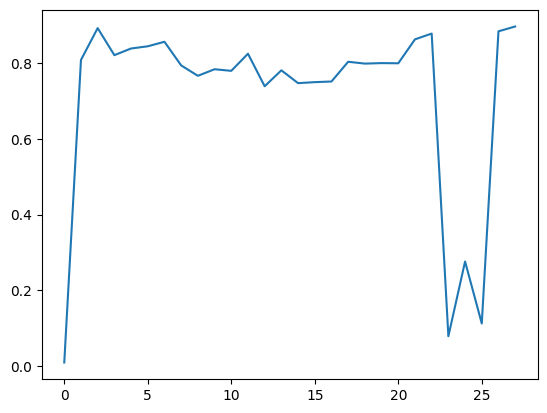

In [9]:
plt.plot(ssims)

In [10]:
print(frame_counter/(end-start))

19.274100652279127
